### Agent Implementations: self-play

#### verS1 stands for S: small - size of board (4x5 board - 16 pieces), 1: self-play
*Note: all configs, parameters and hyperparameters used in this phase are available in "../implementations/verS1_configs.txt"

versions guide:

- X - {0: no, 1: yes}
- S1XYYYY, X - Is Double Net
- S1YXYYY, X - Is Dueling Net
- S1YYXYY, X - Is Residual Net
- S1YYYXY, X - Is Canonical
- S1YYYYX, X - Will do reward shaping
- S1YYYYYR, R - After refactor

#### Canonical vs Absolute Perspective

Log analysis:

| ver | label | eval max Q | eval min Q | avg Q (first eval) | avg Q (last eval) | max eval TD error | best eval win% white | best eval win% black | end eval win% white | end eval win% black | end train win gap | best train draw% (lowest) | **end train draw% (last)** |
|---|---|---|---|---|---|---|----------------------|----------------------|---------------------|---------------------|-------------------|---|---|
| S110110 | Canonical Residual DDQN | 0.5644 | -0.8632 | 0.0083 | 0.2478 | 1.0539 | 88.5%                | 83.0%                | 86.0%               | 83.0%               | 7.6%              | 25.6% | **25.6%** |
| S110100 | Absolute Perspective Residual DDQN | 0.3757 | -1.0053 | -0.0080 | 0.1642 | 1.0251 | 86.5%                | 77.5%                | 84.0%               | 77.5%               | 6.3%              | 30.3% | **30.3%** |

Regardless of state representation of the board, to always be flipped as white perspective or represented "as it is" from absolute perspective and with additional signal - who is on turn, my assumption is that regardless of choice, color bias is existing because size of the board. In other words when average number of env steps per game is 54 -> 30 that start one move of white matters more, but that is only hypothesis. But even of this, canonical version managed to lower decisive draws by more than a half from baseline and showed slightly better results on evaluations against random opponent than absolute perspective implementation did. Every further implementation will include canonical version as base.

#### Further Training (self-play vs no-self-play)

As shown in *"verS0.ipnyb"* Residual DDQN that is trained against random have 86% win rate as white on evaluation against random which is same as Residual DDQN that is self-play evaluation win rate as white against random. But Residual DDQN trained against random performed worse than certain implementations that had worse evaluation win rate as white against random. So before going deeper into training I would like to check how self-play performs against random opponent training version.

In [1]:
from agent.grenight_agent import GrenightAgent
from agent.helpers.load_checkpoint import load_checkpoint
from agent.helpers.agents_duel import test_agents

self_play = GrenightAgent(True, True, False, True, 12, 5, 4, 420)
load_checkpoint(self_play, "S110110", 10_000)

no_self_play = GrenightAgent(False, True, False, True, 12, 5, 4, 440)
load_checkpoint(no_self_play, "S010100", 10_000)

print(test_agents(self_play, no_self_play, "self-play", "no_self_play", True, False))
print()
print(test_agents(no_self_play, self_play, "no_self_play", "self-play", False, True))

white=self-play, black=no_self_play
Outcomes: Counter({'white_win': 840, 'draw': 149, 'black_win': 11})

white=no_self_play, black=self-play
Outcomes: Counter({'black_win': 902, 'draw': 84, 'white_win': 14})


Unlike no-self-play which was only good for random opponent and bad against trained one, self-play was producing good results in both scenarios. In other words, implementation that is trained against random opponent had extreme loss on both seats, with that given every further training will include self-play as base, and I am ranking self-play to be first criteria for results-chasing choice.

#### Base vs Base + Additions

Current base implementation so far is:
- Double Deep Q Network (instead of just policy net)
- Residual blocks (instead of just fewer conv layers)
- Canonical version - always playing as white (instead of absolute perspective)

Additions that were tested:
- Dueling Double Deep Q Network
- Reward shaping: more penalty to draws and potential bonus reward based on material
- Both

*Note: labels of implementations in this section will be reduced because of size, but it can be clearly mapped from log analysis table*

Log analysis:

| ver | full label | short label | eval max Q | eval min Q | avg Q (first eval) | avg Q (last eval) | max eval TD error | best eval win% white | best eval win% black | end eval win% white | end eval win% black | end train win gap | best train draw% (lowest) | **end train draw% (last)** |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| S110110 | Canonical Residual DDQN | base | 0.5644 | -0.8632 | 0.0083 | 0.2478 | 1.0539 | 88.5% | 83.0% | 86.0% | 83.0% | 7.6% | 25.6% | **25.6%** |
| S111110 | Canonical Residual Dueling DDQN | base + dueling | 0.5787 | -0.8887 | 0.1153 | 0.3745 | 1.0130 | 91.5% | 88.5% | 87.0% | 87.0% | 17.2% | 25.7% | **28.8%** |
| S110111 | Canonical Reward Shaping Residual DDQN | base + reward shaping | 0.6135 | -1.0000 | -0.0337 | 0.3598 | 2.1259 | 86.5% | 85.5% | 79.0% | 83.5% | 8.9% | 35.3% | **34.5%** |
| S111111 | Canonical Reward Shaping Residual Dueling DDQN | base + dueling + reward shaping | 0.6878 | -1.0000 | -0.0425 | 0.4010 | 2.1259 | 87.5% | 87.5% | 85.0% | 79.0% | 2.1% | 26.4% | **37.3%** |

#### Implementations Tournament

Before coming with conclusions, agent implementations tournament will be held to have better picture.

In [1]:
import matplotlib.pyplot as plt
from domain.configs import ROWS, COLUMNS
from environment.grenight_environment import GrenightEnvironment
from agent.grenight_agent import GrenightAgent
from agent.helpers.load_checkpoint import load_checkpoint
from agent.helpers.agents_duel import test_agents
from agent.helpers.renders import (build_decisive_win_matrix,
                                   build_overall_decisive_scores,
                                   build_same_impl_draw_scores,
                                   plot_heatmap,
                                   plot_ranking,
                                   plot_same_impl_draw_ranking,
                                   parse_games)

In [2]:
env = GrenightEnvironment(is_canonical_version=True)

num_planes = env.state_encoder.num_planes
num_actions = env.action_encoder.num_actions

Base = GrenightAgent(
    True, True, False, True,
    num_planes, ROWS, COLUMNS, num_actions
)
load_checkpoint(Base, "S110110", 10_000)

BaseDueling = GrenightAgent(
    True, True, True, True,
    num_planes, ROWS, COLUMNS, num_actions
)
load_checkpoint(BaseDueling, "S111110", 10_000)

BaseRewardShaping = GrenightAgent(
    True, True, False, True,
    num_planes, ROWS, COLUMNS, num_actions
)
load_checkpoint(BaseRewardShaping, "S110111", 10_000)

BaseDuelingRewardShaping = GrenightAgent(
    True, True, True, True,
    num_planes, ROWS, COLUMNS, num_actions
)
load_checkpoint(BaseDuelingRewardShaping, "S111111", 10_000)

agents_dict = {
    "base": Base,
    "base_dueling": BaseDueling,
    "base_reward_shaping": BaseRewardShaping,
    "base_dueling_reward_shaping": BaseDuelingRewardShaping
}

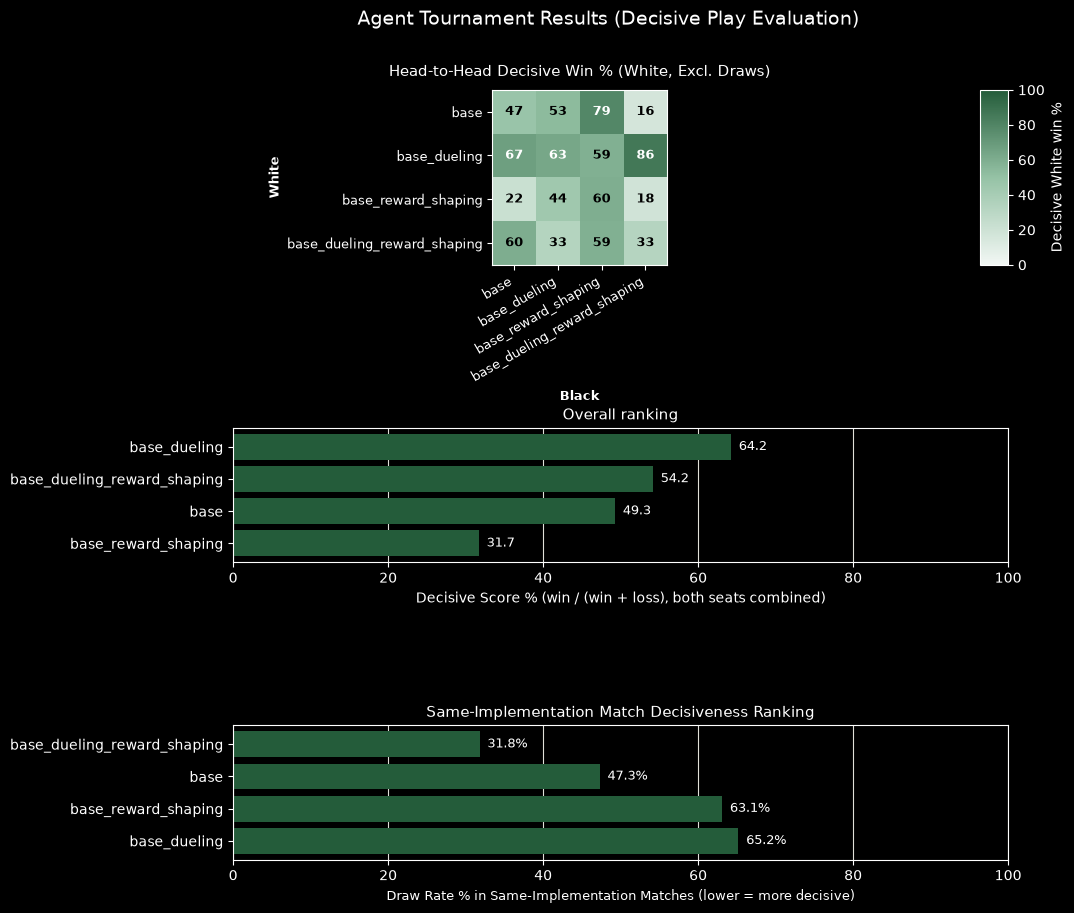

In [3]:
raw_logs = []
for white_name, white_agent in agents_dict.items():
    for black_name, black_agent in agents_dict.items():
        match_result = test_agents(
            white_agent, black_agent, white_name, black_name
        )
        raw_logs.append(match_result)

all_raw_logs = "\n".join(raw_logs)
games = parse_games(all_raw_logs)

matrix = build_decisive_win_matrix(games, agents_dict)
scores = build_overall_decisive_scores(games)
same_impl_scores = build_same_impl_draw_scores(games, agents_dict)

fig = plt.figure(figsize=(10, 10))
gs = fig.add_gridspec(
    3,
    2,
    height_ratios=[1.3, 1, 1],
    width_ratios=[1, 0.04],
    hspace=1.1,
    wspace=0.15
)

ax_main = fig.add_subplot(gs[0, 0])
ax_cbar = fig.add_subplot(gs[0, 1])
ax_rank = fig.add_subplot(gs[1, :])
ax_same_impl = fig.add_subplot(gs[2, :])

im1 = plot_heatmap(
    ax_main,
    matrix,
    "Head-to-Head Decisive Win % (White, Excl. Draws)",
    {k: k for k in agents_dict.keys()}
)

plot_ranking(
    ax_rank,
    scores,
    {k: k for k in agents_dict.keys()}
)

plot_same_impl_draw_ranking(
    ax_same_impl,
    same_impl_scores,
    {k: k for k in agents_dict.keys()}
)

fig.colorbar(im1, cax=ax_cbar, label="Decisive White win %")
fig.suptitle("Agent Tournament Results (Decisive Play Evaluation)", fontsize=14, y=0.96)

plt.show()

#### Conclusion

This time training logs and implementations tournament are more consistent, dueling addition now doesn't have the worst training stats unlike in no-self-play, in fact training stats are on same level as base, and significantly has more wins against other trained agents while producing more draws on self-play simulation. Reward shaping training stats and data from implementations tournament are consistent too, on both is on the worst end, and will be changed for further training, note that is "best" for draw decisiveness but when looking at heatmap has only 33% wins on white seat so it's not relevant it means is just producing more lost matches. Dueling and reward shaping combination is consistent too with other data, reward shaping wears dueling down. Dueling architecture will be added to base for further training.

#### R-version

Changes after refactor:
- 10 planes instead of 12: removed last 2 planes where in one are represented all white pieces on another black ones, note that first 8 planes already are giving signal of type + color so good network should differ color of piece already
- 50% increased PRBS on all pieces: in previous implementations after 10k episodes there were scenarios that agent went blindly for checks and avoided free material
- random curriculum scenarios: because rooks at beginning are blocked and with random movement not often are developed, so 10% of training were scenarios where rooks are placed into random positions so agent could learn rook movements
- learning rate from 0.0005 to 0.001 and bulk update of network from 5000 to 2500
- epsilon minimum 0.2 instead of 0.05: to increase exploration

First to check would be consistency of checkpoints

In [6]:
from domain.configs import ROWS, COLUMNS
from environment.grenight_environment import GrenightEnvironment
from agent.grenight_agent import GrenightAgent
from agent.helpers.load_checkpoint import load_checkpoint
from agent.helpers.agents_duel import test_agents

In [7]:
env = GrenightEnvironment(is_canonical_version=True)

ref_base_10k = GrenightAgent(
    True, True, False, True,
    10, ROWS, COLUMNS, 420
)
load_checkpoint(ref_base_10k, "S110110R", 10_000)

ref_base_20k = GrenightAgent(
    True, True, False, True,
    10, ROWS, COLUMNS, 420
)
load_checkpoint(ref_base_20k, "S110110R", 20_000)

ref_base_30k = GrenightAgent(
    True, True, False, True,
    10, ROWS, COLUMNS, 420
)
load_checkpoint(ref_base_30k, "S110110R", 30_000)

agents_dict = {
    "ref_base_10k": ref_base_10k,
    "ref_base_20k": ref_base_20k,
    "ref_base_30k": ref_base_30k
}

for white_name, white_agent in agents_dict.items():
    for black_name, black_agent in agents_dict.items():
        if white_name == black_name:
            continue

        if white_name[0:3] == "ref":
            is_left_legacy=False
        else:
            is_left_legacy=True
            print(white_name)

        if black_name[0:3] == "ref":
            is_right_legacy=False
        else:
            is_right_legacy=True
            print(black_name)

        match_result = test_agents(
            white_agent, black_agent, white_name, black_name,
            is_left_canonical=True, is_right_canonical=True,
            is_left_legacy=is_left_legacy, is_right_legacy=is_right_legacy
        )
        print(match_result)

white=ref_base_10k, black=ref_base_20k
Outcomes: Counter({'draw': 51, 'black_win': 40, 'white_win': 9})
white=ref_base_10k, black=ref_base_30k
Outcomes: Counter({'draw': 73, 'white_win': 18, 'black_win': 9})
white=ref_base_20k, black=ref_base_10k
Outcomes: Counter({'white_win': 54, 'draw': 33, 'black_win': 13})
white=ref_base_20k, black=ref_base_30k
Outcomes: Counter({'draw': 56, 'black_win': 22, 'white_win': 22})
white=ref_base_30k, black=ref_base_10k
Outcomes: Counter({'white_win': 73, 'draw': 19, 'black_win': 8})
white=ref_base_30k, black=ref_base_20k
Outcomes: Counter({'white_win': 61, 'draw': 25, 'black_win': 14})


In [10]:
env = GrenightEnvironment(is_canonical_version=True)

ref_base_dueling_10k = GrenightAgent(
    True, True, True, True,
    10, ROWS, COLUMNS, 420
)
load_checkpoint(ref_base_dueling_10k, "S111110R", 10_000)

ref_base_dueling_20k = GrenightAgent(
    True, True, True, True,
    10, ROWS, COLUMNS, 420
)
load_checkpoint(ref_base_dueling_20k, "S111110R", 20_000)

ref_base_dueling_30k = GrenightAgent(
    True, True, True, True,
    10, ROWS, COLUMNS, 420
)
load_checkpoint(ref_base_dueling_30k, "S111110R", 30_000)

agents_dict = {
    "ref_base_dueling_10k": ref_base_dueling_10k,
    "ref_base_dueling_20k": ref_base_dueling_20k,
    "ref_base_dueling_30k": ref_base_dueling_30k
}

for white_name, white_agent in agents_dict.items():
    for black_name, black_agent in agents_dict.items():
        if white_name == black_name:
            continue

        if white_name[0:3] == "ref":
            is_left_legacy=False
        else:
            is_left_legacy=True
            print(white_name)

        if black_name[0:3] == "ref":
            is_right_legacy=False
        else:
            is_right_legacy=True
            print(black_name)

        match_result = test_agents(
            white_agent, black_agent, white_name, black_name,
            is_left_canonical=True, is_right_canonical=True,
            is_left_legacy=is_left_legacy, is_right_legacy=is_right_legacy
        )
        print(match_result)

white=ref_base_dueling_10k, black=ref_base_dueling_20k
Outcomes: Counter({'draw': 77, 'white_win': 15, 'black_win': 8})
white=ref_base_dueling_10k, black=ref_base_dueling_30k
Outcomes: Counter({'draw': 65, 'white_win': 21, 'black_win': 14})
white=ref_base_dueling_20k, black=ref_base_dueling_10k
Outcomes: Counter({'white_win': 78, 'draw': 12, 'black_win': 10})
white=ref_base_dueling_20k, black=ref_base_dueling_30k
Outcomes: Counter({'draw': 60, 'white_win': 26, 'black_win': 14})
white=ref_base_dueling_30k, black=ref_base_dueling_10k
Outcomes: Counter({'white_win': 65, 'draw': 22, 'black_win': 13})
white=ref_base_dueling_30k, black=ref_base_dueling_20k
Outcomes: Counter({'draw': 48, 'white_win': 32, 'black_win': 20})


In [11]:
env = GrenightEnvironment(is_canonical_version=True)

ref_base_dueling_reward_shaping_10k = GrenightAgent(
    True, True, True, True,
    10, ROWS, COLUMNS, 420
)
load_checkpoint(ref_base_dueling_reward_shaping_10k, "S111111R", 10_000)

ref_base_dueling_reward_shaping_20k = GrenightAgent(
    True, True, True, True,
    10, ROWS, COLUMNS, 420
)
load_checkpoint(ref_base_dueling_reward_shaping_20k, "S111111R", 20_000)

ref_base_dueling_reward_shaping_30k = GrenightAgent(
    True, True, True, True,
    10, ROWS, COLUMNS, 420
)
load_checkpoint(ref_base_dueling_reward_shaping_30k, "S111111R", 30_000)

agents_dict = {
    "ref_base_dueling_reward_shaping_10k": ref_base_dueling_reward_shaping_10k,
    "ref_base_dueling_reward_shaping_20k": ref_base_dueling_reward_shaping_20k,
    "ref_base_dueling_reward_shaping_30k": ref_base_dueling_reward_shaping_30k
}

for white_name, white_agent in agents_dict.items():
    for black_name, black_agent in agents_dict.items():
        if white_name == black_name:
            continue

        if white_name[0:3] == "ref":
            is_left_legacy=False
        else:
            is_left_legacy=True
            print(white_name)

        if black_name[0:3] == "ref":
            is_right_legacy=False
        else:
            is_right_legacy=True
            print(black_name)

        match_result = test_agents(
            white_agent, black_agent, white_name, black_name,
            is_left_canonical=True, is_right_canonical=True,
            is_left_legacy=is_left_legacy, is_right_legacy=is_right_legacy
        )
        print(match_result)

white=ref_base_dueling_reward_shaping_10k, black=ref_base_dueling_reward_shaping_20k
Outcomes: Counter({'black_win': 52, 'draw': 32, 'white_win': 16})
white=ref_base_dueling_reward_shaping_10k, black=ref_base_dueling_reward_shaping_30k
Outcomes: Counter({'draw': 48, 'black_win': 40, 'white_win': 12})
white=ref_base_dueling_reward_shaping_20k, black=ref_base_dueling_reward_shaping_10k
Outcomes: Counter({'white_win': 76, 'draw': 13, 'black_win': 11})
white=ref_base_dueling_reward_shaping_20k, black=ref_base_dueling_reward_shaping_30k
Outcomes: Counter({'black_win': 66, 'draw': 24, 'white_win': 10})
white=ref_base_dueling_reward_shaping_30k, black=ref_base_dueling_reward_shaping_10k
Outcomes: Counter({'draw': 53, 'white_win': 31, 'black_win': 16})
white=ref_base_dueling_reward_shaping_30k, black=ref_base_dueling_reward_shaping_20k
Outcomes: Counter({'draw': 58, 'white_win': 28, 'black_win': 14})


#### Conclusion & Testing against before refactor

Further checkpoints of same implementation are better, training is consistent at all new three R implementations. Now they will be tested against implementations before factoring but note that before refactor implementation are trained on 10k episodes newer are on 30k, epsilon decay is not same so the 10k checkpoint of before refactor is not same as 10k of after refactoring. But fact remains that they are distinct because 1/3 of training after refactoring was trained on 0.2 epsilon minimum instead of near 1/2 training at 0.05 epsilon minimum before refactoring.

In [1]:
import matplotlib.pyplot as plt
from domain.configs import ROWS, COLUMNS
from environment.grenight_environment import GrenightEnvironment
from agent.grenight_agent import GrenightAgent
from agent.helpers.load_checkpoint import load_checkpoint
from agent.helpers.agents_duel import test_agents
from agent.helpers.renders import (build_decisive_win_matrix,
                                   build_overall_decisive_scores,
                                   build_same_impl_draw_scores,
                                   plot_heatmap,
                                   plot_ranking,
                                   plot_same_impl_draw_ranking,
                                   parse_games)

In [2]:
env = GrenightEnvironment(is_canonical_version=True)

Base = GrenightAgent(
    True, True, False, True,
    12, ROWS, COLUMNS, 420
)
load_checkpoint(Base, "S110110", 10_000)

BaseDueling = GrenightAgent(
    True, True, True, True,
    12, ROWS, COLUMNS, 420
)
load_checkpoint(BaseDueling, "S111110", 10_000)

BaseRewardShaping = GrenightAgent(
    True, True, False, True,
    12, ROWS, COLUMNS, 420
)
load_checkpoint(BaseRewardShaping, "S110111", 10_000)

BaseDuelingRewardShaping = GrenightAgent(
    True, True, True, True,
    12, ROWS, COLUMNS, 420
)
load_checkpoint(BaseDuelingRewardShaping, "S111111", 10_000)

ref_base_30k = GrenightAgent(
    True, True, False, True,
    10, ROWS, COLUMNS, 420
)
load_checkpoint(ref_base_30k, "S110110R", 30_000)

ref_base_dueling_30k = GrenightAgent(
    True, True, True, True,
    10, ROWS, COLUMNS, 420
)
load_checkpoint(ref_base_dueling_30k, "S111110R", 30_000)

ref_base_dueling_reward_shaping_30k = GrenightAgent(
    True, True, True, True,
    10, ROWS, COLUMNS, 420
)
load_checkpoint(ref_base_dueling_reward_shaping_30k, "S111111R", 30_000)

agents_dict = {
    "base": Base,
    "base_dueling": BaseDueling,
    "base_reward_shaping": BaseRewardShaping,
    "base_dueling_reward_shaping": BaseDuelingRewardShaping,
    "ref_base_30k": ref_base_30k,
    "ref_base_dueling_30k" : ref_base_dueling_30k,
    "ref_base_dueling_reward_shaping_30k" : ref_base_dueling_reward_shaping_30k
}

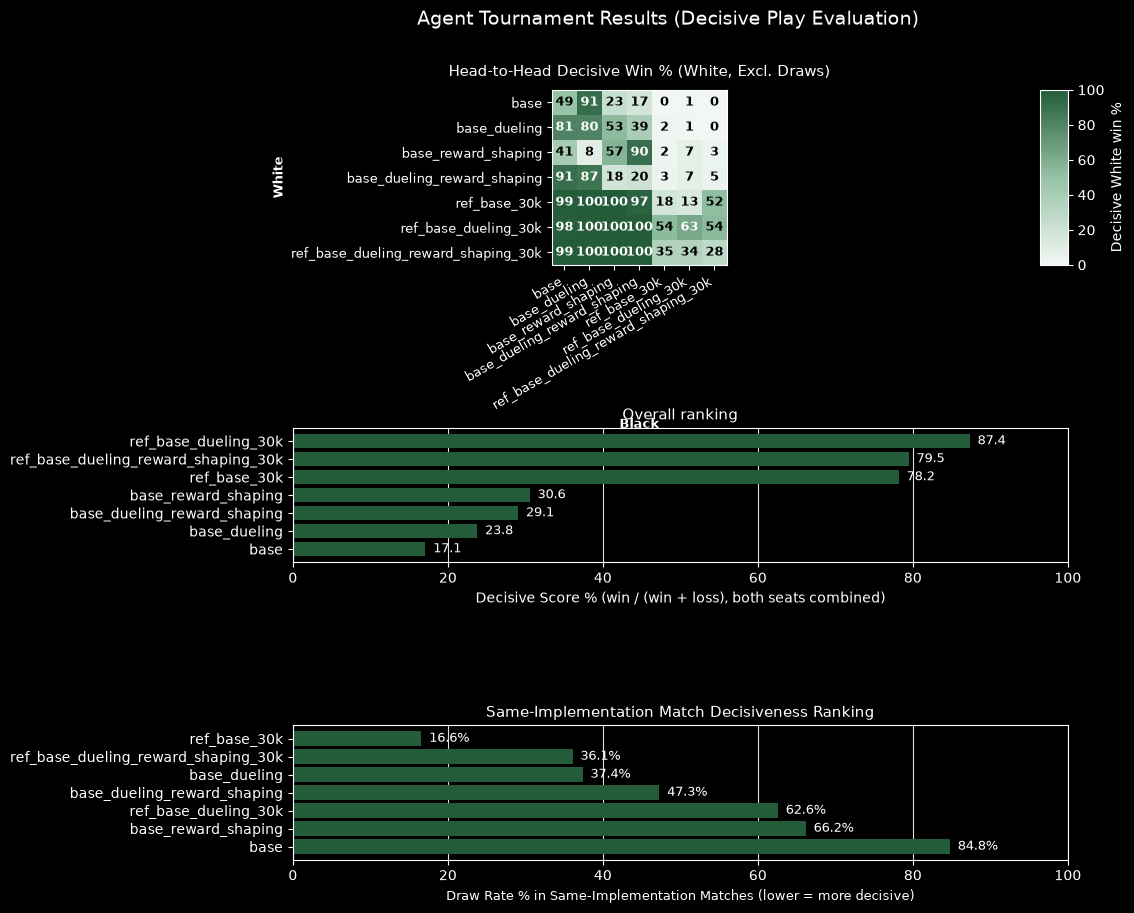

In [4]:
+raw_logs = []
for white_name, white_agent in agents_dict.items():
    for black_name, black_agent in agents_dict.items():
        if white_name[0:3] == "ref":
            is_left_legacy=False
        else:
            is_left_legacy=True

        if black_name[0:3] == "ref":
            is_right_legacy=False
        else:
            is_right_legacy=True

        match_result = test_agents(
            white_agent, black_agent, white_name, black_name,
            is_left_canonical=True, is_right_canonical=True,
            is_left_legacy=is_left_legacy, is_right_legacy=is_right_legacy
        )
        raw_logs.append(match_result)

all_raw_logs = "\n".join(raw_logs)
games = parse_games(all_raw_logs)

matrix = build_decisive_win_matrix(games, agents_dict)
scores = build_overall_decisive_scores(games)
same_impl_scores = build_same_impl_draw_scores(games, agents_dict)

fig = plt.figure(figsize=(10, 10))
gs = fig.add_gridspec(
    3,
    2,
    height_ratios=[1.3, 1, 1],
    width_ratios=[1, 0.04],
    hspace=1.1,
    wspace=0.15
)

ax_main = fig.add_subplot(gs[0, 0])
ax_cbar = fig.add_subplot(gs[0, 1])
ax_rank = fig.add_subplot(gs[1, :])
ax_same_impl = fig.add_subplot(gs[2, :])

im1 = plot_heatmap(
    ax_main,
    matrix,
    "Head-to-Head Decisive Win % (White, Excl. Draws)",
    {k: k for k in agents_dict.keys()}
)

plot_ranking(
    ax_rank,
    scores,
    {k: k for k in agents_dict.keys()}
)

plot_same_impl_draw_ranking(
    ax_same_impl,
    same_impl_scores,
    {k: k for k in agents_dict.keys()}
)

fig.colorbar(im1, cax=ax_cbar, label="Decisive White win %")
fig.suptitle("Agent Tournament Results (Decisive Play Evaluation)", fontsize=14, y=0.96)

plt.show()